In [1]:
# Cell 1 — Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Cell 2 — Load and explore the dataset
df = pd.read_csv('../data/creditcard.csv')

# Basic info
print("Dataset loaded successfully")
print(f"\n Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n Column Names:\n{list(df.columns)}")
print(f"\n First 5 rows:")
df.head()

Dataset loaded successfully

 Shape: 284807 rows, 31 columns

 Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

 First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class Distribution:
   Normal transactions : 284315 (99.83%)
   Fraud  transactions : 492  (0.17%)
   Total               : 284807

 Imbalance ratio: 1 fraud for every 578 normal transactions


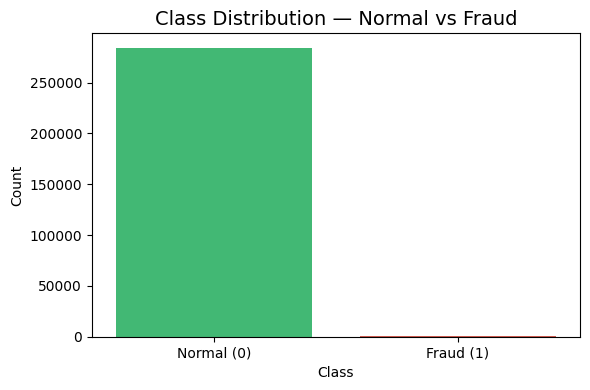

Chart saved as class_distribution.png


In [3]:
# Cell 3 — Check class imbalance
normal = df['Class'].value_counts()[0]
fraud = df['Class'].value_counts()[1]
total = len(df)

print("Class Distribution:")
print(f"   Normal transactions : {normal} ({round(normal/total*100, 2)}%)")
print(f"   Fraud  transactions : {fraud}  ({round(fraud/total*100, 2)}%)")
print(f"   Total               : {total}")

print(f"\n Imbalance ratio: 1 fraud for every {round(normal/fraud)} normal transactions")

# Plot it visually
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Class Distribution — Normal vs Fraud', fontsize=14)
plt.xticks([0,1], ['Normal (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/class_distribution.png')
plt.show()

print("Chart saved as class_distribution.png")

In [4]:
# Cell 4 — Check data quality
print("Missing Values Check:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found — dataset is clean!")
else:
    print(missing[missing > 0])

print("\n Data Types:")
print(df.dtypes)

print("\n Basic Statistics for Amount column:")
print(f"   Min    : {df['Amount'].min()}")
print(f"   Max    : {df['Amount'].max()}")
print(f"   Mean   : {round(df['Amount'].mean(), 2)}")
print(f"   Median : {round(df['Amount'].median(), 2)}")

print("\n Basic Statistics for Time column:")
print(f"   Min    : {df['Time'].min()}")
print(f"   Max    : {df['Time'].max()}")

# Compare amount in fraud vs normal
print("\n Average Amount — Fraud vs Normal:")
print(df.groupby('Class')['Amount'].mean().rename({0:'Normal', 1:'Fraud'}))

Missing Values Check:
No missing values found — dataset is clean!

 Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

 Basic Statistics for Amount column:
   Min    : 0.0
   Max    : 25691.16
   Mean   : 88.35
   Median : 22.0

 Basic Statistics for Time column:
   Min    : 0.0
   Max    : 172792.0

 Average Amount — Fraud vs Normal:
Class
Normal     88.291022
Fraud     122.211321
Name: Amount, dtype: float64


Features and target separated

 Input features (X) shape  : (284807, 30)
 Target label  (y) shape  : (284807,)

 Feature columns (30 total):
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

 Top 10 features most correlated with Fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


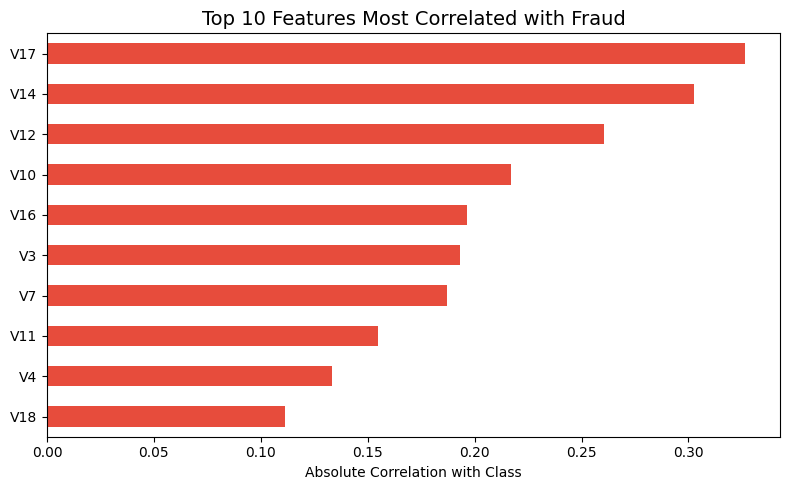


 Correlation chart saved as correlation_heatmap.png


In [5]:
# Cell 5 — Feature Selection

# Step 1 — Separate input features and target label
X = df.drop(columns=['Class'])   # everything except Class
y = df['Class']                  # only Class column (0 or 1)

print("Features and target separated")
print(f"\n Input features (X) shape  : {X.shape}")
print(f" Target label  (y) shape  : {y.shape}")

# Step 2 — Check what columns are in X
print(f"\n Feature columns ({len(X.columns)} total):")
print(list(X.columns))

# Step 3 — Correlation of each feature with fraud
print("\n Top 10 features most correlated with Fraud:")
correlation = df.corr()['Class'].drop('Class')
top_10 = correlation.abs().sort_values(ascending=False).head(10)
print(top_10)

# Plot correlation
plt.figure(figsize=(8,5))
top_10.sort_values().plot(kind='barh', color='#e74c3c')
plt.title('Top 10 Features Most Correlated with Fraud', fontsize=14)
plt.xlabel('Absolute Correlation with Class')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png')
plt.show()

print("\n Correlation chart saved as correlation_heatmap.png")

In [6]:
# Cell 6 — Scale Amount and Time using StandardScaler

scaler = StandardScaler()

# Step 1 — Scale Amount and Time columns only
# V1 to V28 are already scaled by the bank — we don't touch them
X['Amount_Scaled'] = scaler.fit_transform(X[['Amount']])
X['Time_Scaled']   = scaler.fit_transform(X[['Time']])

# Step 2 — Drop original Amount and Time columns
X = X.drop(columns=['Amount', 'Time'])

print(" Amount and Time scaled successfully")
print(f"\n X shape after scaling : {X.shape}")

print("\n Final feature columns:")
print(list(X.columns))

# Step 3 — Verify scaling worked
print("\n Amount_Scaled stats (should be around 0 mean):")
print(f"   Mean : {round(X['Amount_Scaled'].mean(), 4)}")
print(f"   Std  : {round(X['Amount_Scaled'].std(), 4)}")
print(f"   Min  : {round(X['Amount_Scaled'].min(), 4)}")
print(f"   Max  : {round(X['Amount_Scaled'].max(), 4)}")

# Step 4 — Save the scaler — we need this later in Flask API
joblib.dump(scaler, '../models/scaler.pkl')
print("\n scaler.pkl saved inside models/ folder")

 Amount and Time scaled successfully

 X shape after scaling : (284807, 30)

 Final feature columns:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_Scaled', 'Time_Scaled']

 Amount_Scaled stats (should be around 0 mean):
   Mean : -0.0
   Std  : 1.0
   Min  : -0.3532
   Max  : 102.3622

 scaler.pkl saved inside models/ folder


In [7]:
# Cell 7 — Split data into Train and Test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # same split every time you run
    stratify=y            # keep same fraud ratio in both splits
)

print("Data split successfully")
print(f"\n Training set size   : {X_train.shape[0]} rows")
print(f" Testing  set size   : {X_test.shape[0]} rows")

print(f"\n Fraud distribution in Training set:")
train_normal = (y_train == 0).sum()
train_fraud  = (y_train == 1).sum()
print(f"   Normal : {train_normal} ({round(train_normal/len(y_train)*100, 2)}%)")
print(f"   Fraud  : {train_fraud}  ({round(train_fraud/len(y_train)*100, 2)}%)")

print(f"\n Fraud distribution in Testing set:")
test_normal = (y_test == 0).sum()
test_fraud  = (y_test == 1).sum()
print(f"   Normal : {test_normal} ({round(test_normal/len(y_test)*100, 2)}%)")
print(f"   Fraud  : {test_fraud}  ({round(test_fraud/len(y_test)*100, 2)}%)")

print(f"\n Rule check — stratify worked correctly:")
train_ratio = round(train_fraud/len(y_train)*100, 2)
test_ratio  = round(test_fraud/len(y_test)*100, 2)
if abs(train_ratio - test_ratio) < 0.1:
    print(f"   Fraud ratio is same in both sets (~{train_ratio}%)")
else:
    print(f"   Ratios differ — something went wrong")

Data split successfully

 Training set size   : 227845 rows
 Testing  set size   : 56962 rows

 Fraud distribution in Training set:
   Normal : 227451 (99.83%)
   Fraud  : 394  (0.17%)

 Fraud distribution in Testing set:
   Normal : 56864 (99.83%)
   Fraud  : 98  (0.17%)

 Rule check — stratify worked correctly:
   Fraud ratio is same in both sets (~0.17%)


Applying SMOTE — this takes 1-2 minutes, please wait...
 SMOTE applied successfully

 Before SMOTE — Training set:
   Normal : 227451
   Fraud  : 394

 After SMOTE — Training set:
   Normal : 227451
   Fraud  : 227451

 Total training rows after SMOTE : 454902


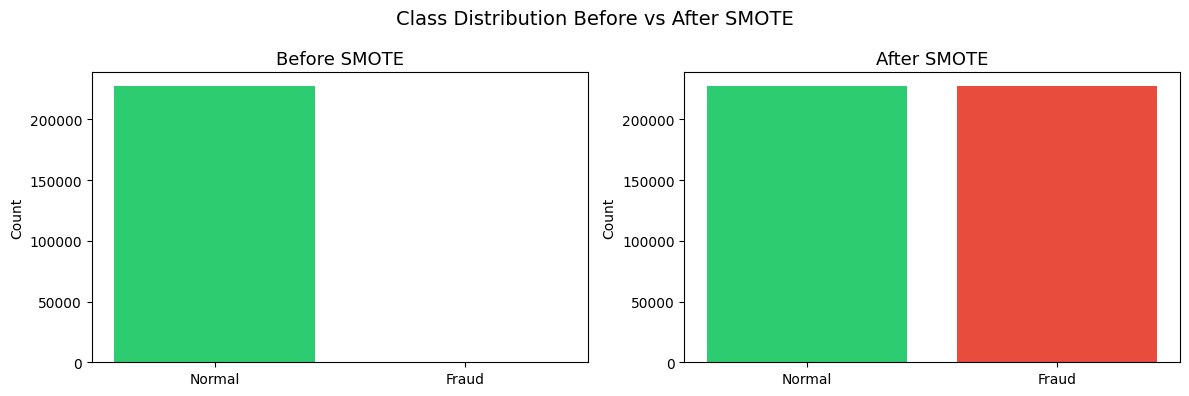

Chart saved as smote_comparison.png


In [8]:
# Cell 8 — Fix class imbalance using SMOTE

print("Applying SMOTE — this takes 1-2 minutes, please wait...")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(" SMOTE applied successfully")

print(f"\n Before SMOTE — Training set:")
print(f"   Normal : {(y_train == 0).sum()}")
print(f"   Fraud  : {(y_train == 1).sum()}")

print(f"\n After SMOTE — Training set:")
print(f"   Normal : {(y_train_smote == 0).sum()}")
print(f"   Fraud  : {(y_train_smote == 1).sum()}")

print(f"\n Total training rows after SMOTE : {len(X_train_smote)}")

# Plot before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].bar(['Normal', 'Fraud'],
            [(y_train == 0).sum(), (y_train == 1).sum()],
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE', fontsize=13)
axes[0].set_ylabel('Count')

# After
axes[1].bar(['Normal', 'Fraud'],
            [(y_train_smote == 0).sum(), (y_train_smote == 1).sum()],
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE', fontsize=13)
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=14)
plt.tight_layout()
plt.savefig('../data/smote_comparison.png')
plt.show()

print("Chart saved as smote_comparison.png")

In [9]:
# Cell 9 — Train the XGBoost model

print("Training XGBoost model — this takes 2-3 minutes, please wait...")

model = XGBClassifier(
    n_estimators=200,        # 200 decision trees
    max_depth=6,             # how deep each tree grows
    learning_rate=0.1,       # how fast model learns
    scale_pos_weight=1,      # balanced because we used SMOTE
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print("Model trained successfully!")

# Quick check — predict on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"\n Quick accuracy check:")
print(f"   Total test rows    : {len(y_test)}")
print(f"   Correct predictions: {(y_pred == y_test).sum()}")
print(f"   Wrong  predictions : {(y_pred != y_test).sum()}")
print(f"   Basic accuracy     : {round((y_pred == y_test).sum()/len(y_test)*100, 4)}%")

print(f"\n ROC AUC Score : {round(roc_auc_score(y_test, y_pred_proba), 4)}")
print("   (1.0 = perfect, 0.5 = random guessing)")

Training XGBoost model — this takes 2-3 minutes, please wait...
Model trained successfully!

 Quick accuracy check:
   Total test rows    : 56962
   Correct predictions: 56894
   Wrong  predictions : 68
   Basic accuracy     : 99.8806%

 ROC AUC Score : 0.9769
   (1.0 = perfect, 0.5 = random guessing)


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.61      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix Breakdown:
    True  Normal  (correct)     : 56809
    True  Fraud   (correct)     : 85
    False Positive (wrong alert): 55
    False Negative (missed fraud): 13

 Key Metrics:
   Precision : 60.71%  (of all fraud alerts, how many were real fraud)
   Recall    : 86.73%  (of all real frauds, how many did we catch)
   ROC AUC   : 97.69%


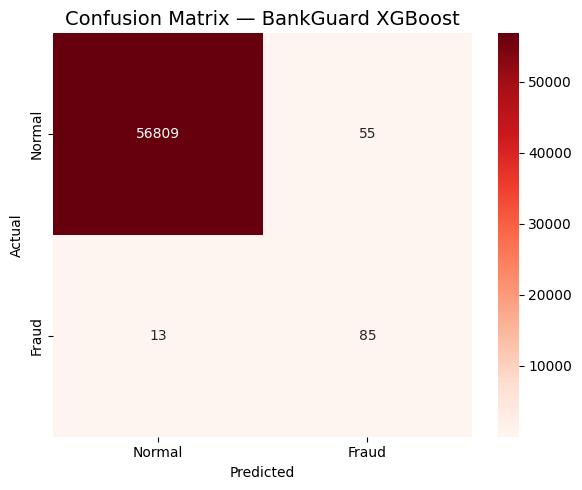

Confusion matrix saved as confusion_matrix.png


In [10]:
# Cell 10 — Full model evaluation

print("Classification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=['Normal', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

tn = cm[0][0]  # True Normal  — predicted Normal,  actually Normal
fp = cm[0][1]  # False Positive — predicted Fraud,  actually Normal
fn = cm[1][0]  # False Negative — predicted Normal,  actually Fraud
tp = cm[1][1]  # True Positive  — predicted Fraud,  actually Fraud

print(f"Confusion Matrix Breakdown:")
print(f"    True  Normal  (correct)     : {tn}")
print(f"    True  Fraud   (correct)     : {tp}")
print(f"    False Positive (wrong alert): {fp}")
print(f"    False Negative (missed fraud): {fn}")

print(f"\n Key Metrics:")
precision = round(tp/(tp+fp)*100, 2)
recall    = round(tp/(tp+fn)*100, 2)
print(f"   Precision : {precision}%  (of all fraud alerts, how many were real fraud)")
print(f"   Recall    : {recall}%  (of all real frauds, how many did we catch)")
print(f"   ROC AUC   : {round(roc_auc_score(y_test, y_pred_proba)*100, 2)}%")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix — BankGuard XGBoost', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()

print("Confusion matrix saved as confusion_matrix.png")

Top 15 Most Important Features:
      Feature  Importance
          V14    0.563952
           V4    0.055411
          V12    0.035447
           V8    0.034824
          V18    0.019032
          V13    0.018896
          V17    0.017720
           V3    0.016535
          V26    0.016266
           V1    0.015837
          V10    0.014755
  Time_Scaled    0.014466
Amount_Scaled    0.013877
           V7    0.012375
          V25    0.011944


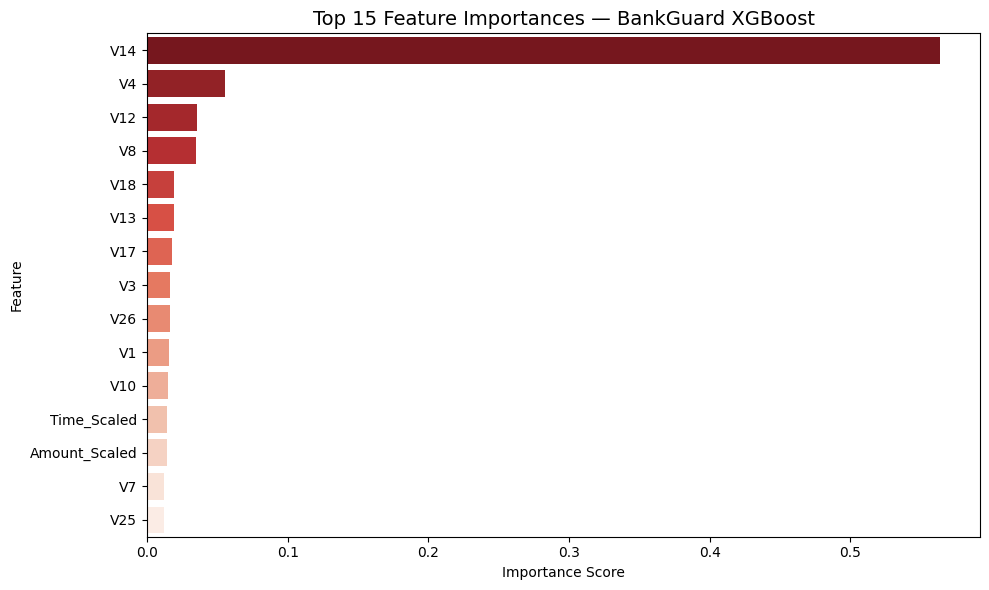


 Feature importance chart saved as feature_importance.png

 Key Insight:
   Top 3 features your model relies on most:
   1. V14 — importance score: 0.5640000104904175
   2. V4 — importance score: 0.055399999022483826
   3. V12 — importance score: 0.03539999946951866


In [11]:
# Cell 11 — Feature Importance Chart

# Get feature importance from trained model
importance = model.feature_importances_
feature_names = X_train_smote.columns.tolist()

# Create dataframe for easy sorting
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

# Plot top 15
plt.figure(figsize=(10, 6))
top_15 = importance_df.head(15)
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_15,
    palette='Reds_r'
)
plt.title('Top 15 Feature Importances — BankGuard XGBoost', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()

print("\n Feature importance chart saved as feature_importance.png")

# Key insight
print("\n Key Insight:")
top_3 = importance_df.head(3)['Feature'].tolist()
print(f"   Top 3 features your model relies on most:")
for i, f in enumerate(top_3, 1):
    score = importance_df[importance_df['Feature']==f]['Importance'].values[0]
    print(f"   {i}. {f} — importance score: {round(score, 4)}")

In [12]:
# Cell 12 — Save the trained model

import os

# Make sure models/ folder exists
os.makedirs('../models', exist_ok=True)

# Step 1 — Save the trained XGBoost model
joblib.dump(model, '../models/fraud_model.pkl')
print("fraud_model.pkl saved successfully")

# Step 2 — Save feature names list
# Flask API needs exact column order — same as training
feature_names = X_train_smote.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')
print("feature_names.pkl saved successfully")

# Step 3 — Verify all files saved correctly
print("\n Files inside models/ folder:")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}')
    print(f"   {f} — {round(size/1024, 1)} KB")

# Step 4 — Test loading the model back
print("\n Testing model reload...")
loaded_model  = joblib.load('../models/fraud_model.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')
loaded_features = joblib.load('../models/feature_names.pkl')

print(f"    fraud_model.pkl  loaded — type: {type(loaded_model).__name__}")
print(f"    scaler.pkl       loaded — type: {type(loaded_scaler).__name__}")
print(f"    feature_names.pkl loaded — {len(loaded_features)} features")

# Step 5 — Quick prediction test with loaded model
print("\n Quick prediction test with loaded model:")
sample = X_test.iloc[0:1]   # take first test row
pred        = loaded_model.predict(sample)[0]
pred_proba  = loaded_model.predict_proba(sample)[0][1]
actual      = y_test.iloc[0]

print(f"   Sample transaction:")
print(f"   Actual label    : {'Fraud' if actual == 1 else 'Normal'}")
print(f"   Model predicted : {'Fraud' if pred == 1 else 'Normal'}")
print(f"   Fraud probability: {round(pred_proba * 100, 2)}%")

# Step 6 — Map probability to risk level
if pred_proba >= 0.7:
    risk = "HIGH   → BLOCK transaction + send SMS"
elif pred_proba >= 0.4:
    risk = "MEDIUM → FLAG transaction + send OTP"
else:
    risk = "LOW    → APPROVE transaction"

print(f"   Risk Level      : {risk}")

print("\n Model saved and verified — ready for Flask API!")

fraud_model.pkl saved successfully
feature_names.pkl saved successfully

 Files inside models/ folder:
   feature_names.pkl — 0.2 KB
   fraud_model.pkl — 635.3 KB
   scaler.pkl — 0.8 KB

 Testing model reload...
    fraud_model.pkl  loaded — type: XGBClassifier
    scaler.pkl       loaded — type: StandardScaler
    feature_names.pkl loaded — 30 features

 Quick prediction test with loaded model:
   Sample transaction:
   Actual label    : Normal
   Model predicted : Normal
   Fraud probability: 0.0%
   Risk Level      : LOW    → APPROVE transaction

 Model saved and verified — ready for Flask API!
